# FAPE, Lending Club EDA
## Financial Services Domain, Loan Default Analysis

**Dataset:** Lending Club Loan Data, Kaggle (wordsforthewise/lending-club), 2007-2018 Q4  
**Sample:** 100,000 records from 1,348,099 total  
**Target:** loan_default_binary (1=default, 0=fully paid)  
**Sensitive attributes:** annual_inc_band, emp_length, home_ownership, addr_state  
**Domain:** Financial Services  

**Important note:** Lending Club does not collect race or gender data, ECOA compliance. Socioeconomic proxies (income, housing, employment) used per fairness literature standard. Follows Kozodoi et al. (2022) preprocessing for financial fairness evaluation.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lending_club_loader import load_lending_club

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

GRADE_LABELS = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G'}
HOME_LABELS = {0:'ANY',1:'MORTGAGE',2:'NONE',3:'OTHER',4:'OWN',5:'RENT'}
INC_LABELS = {-1:'Unknown',0:'Low',1:'Lower-Mid',2:'Upper-Mid',3:'High'}
PURPOSE_LABELS = {0:'car',1:'credit_card',2:'debt_consolidation',3:'educational',
                  4:'home_improvement',5:'house',6:'major_purchase',7:'medical',
                  8:'moving',9:'other',10:'renewable_energy',11:'small_business',
                  12:'vacation',13:'wedding'}
print('Imports complete')

Imports complete


In [2]:
dataset = load_lending_club(sample_size=500000, data_path='../data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv')
data = dataset['lending_club']
df = pd.concat([data['X'], data['y']], axis=1)
df.columns = list(data['X'].columns) + ['label']
df['grade_label'] = df['grade'].map(GRADE_LABELS)
df['home_label'] = df['home_ownership'].map(HOME_LABELS)
df['inc_label'] = df['annual_inc_band'].map(INC_LABELS)
print(f'Shape: {df.shape}')
print(f'Default rate: {df["label"].mean():.1%}')
print(f'Sample: 500,000 from 1,348,099 total')

Loading Lending Club data from ../data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv...


  Raw records: 2,260,701
  After binary outcome filter: 1,348,099


  Sampled to: 500,000 records
  OK: lending_club: 500,000 rows | 23 features | default rate: 0.200
Shape: (500000, 27)
Default rate: 20.0%
Sample: 500,000 from 1,348,099 total


## 1. Label Distribution, 20% Default Rate

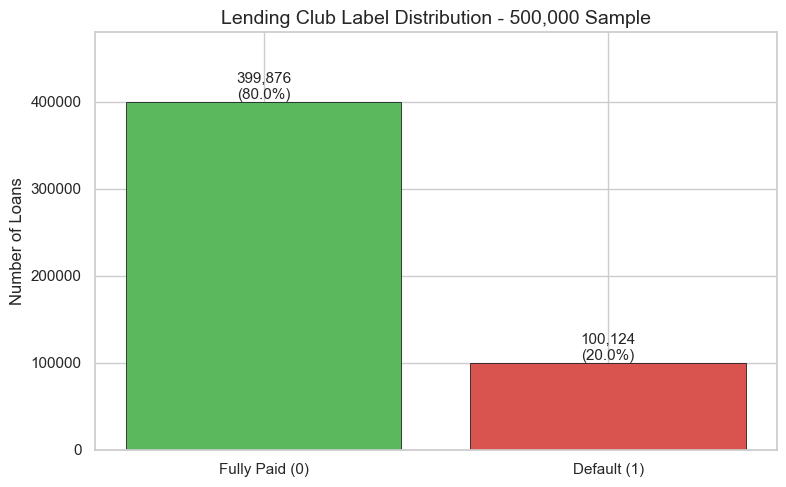

In [3]:
label_counts = df['label'].value_counts().sort_index()
label_pct = df['label'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(['Fully Paid (0)','Default (1)'], label_counts.values,
              color=['#5cb85c','#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000,
            f'{val:,}\n({pct:.1%})', ha='center', fontsize=11)
ax.set_title('Lending Club Label Distribution - 500,000 Sample', fontsize=14)
ax.set_ylabel('Number of Loans')
ax.set_ylim(0, max(label_counts.values)*1.2)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Loan Grade vs Default Rate, Strongest Predictor

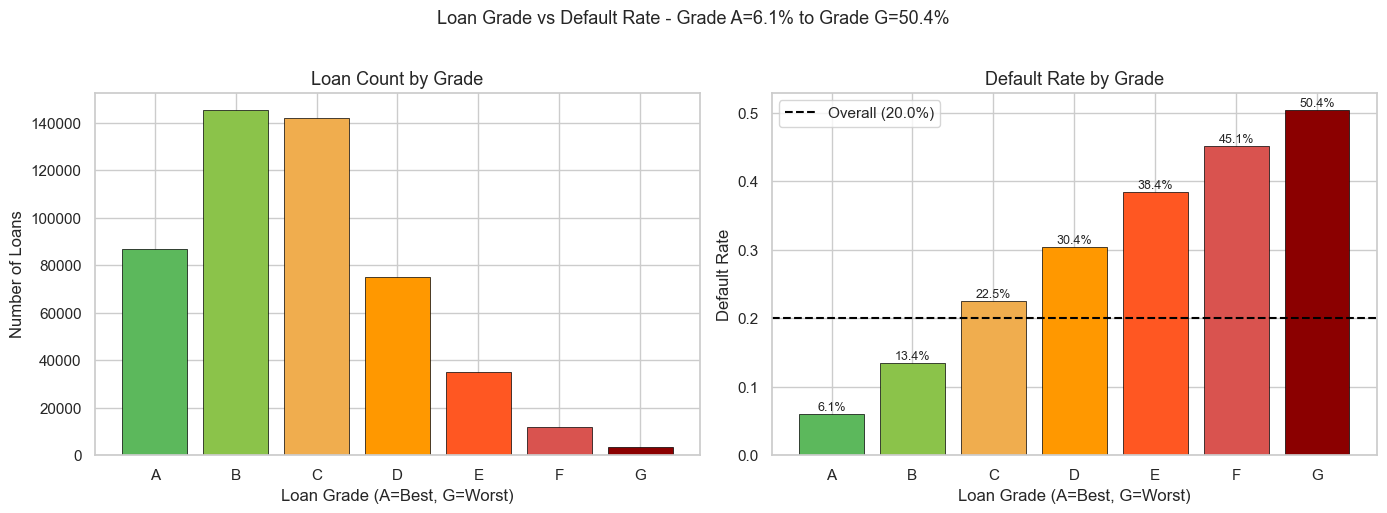

In [4]:
grade_stats = df.groupby('grade_label').agg(count=('label','count'), default_rate=('label','mean')).reset_index()
grade_order = ['A','B','C','D','E','F','G']
grade_stats = grade_stats.set_index('grade_label').reindex(grade_order).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))
colors = ['#5cb85c','#8BC34A','#f0ad4e','#FF9800','#FF5722','#d9534f','#8B0000']

ax1.bar(grade_stats['grade_label'], grade_stats['count'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Loan Count by Grade', fontsize=13)
ax1.set_ylabel('Number of Loans')
ax1.set_xlabel('Loan Grade (A=Best, G=Worst)')

ax2.bar(grade_stats['grade_label'], grade_stats['default_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Default Rate by Grade', fontsize=13)
ax2.set_ylabel('Default Rate')
ax2.set_xlabel('Loan Grade (A=Best, G=Worst)')
ax2.legend()
for i, (_, row) in enumerate(grade_stats.iterrows()):
    ax2.text(i, row['default_rate']+0.005, f'{row["default_rate"]:.1%}', ha='center', fontsize=9)

plt.suptitle('Loan Grade vs Default Rate - Grade A=6.1% to Grade G=50.4%', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_grade_default.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Home Ownership vs Default Rate

Note: ANY (n=123), NONE (n=21), OTHER (n=54) have very small samples, interpret with caution.

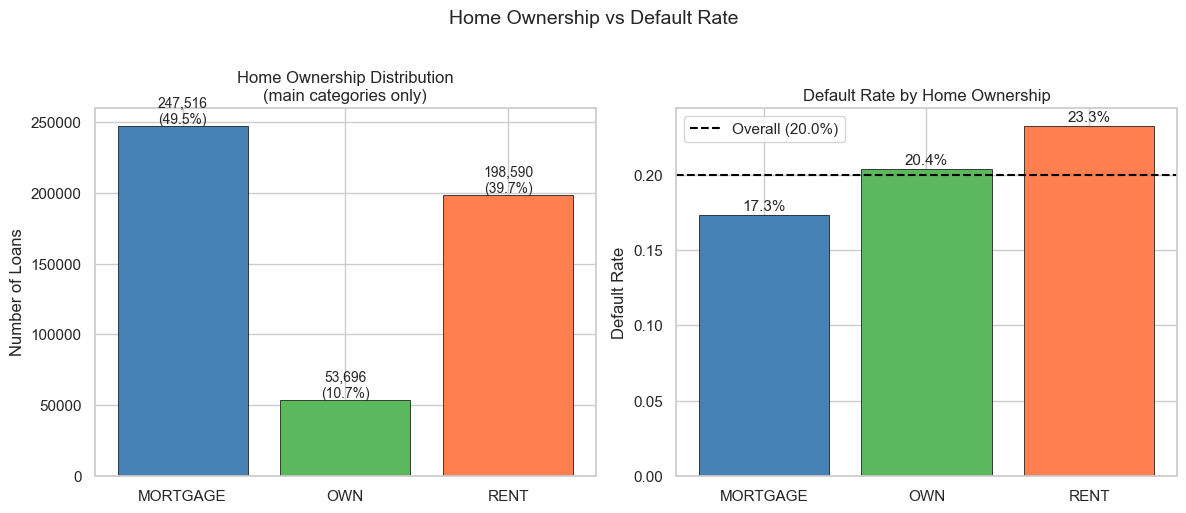

Housing gap: RENT 23.3% vs MORTGAGE 17.3%


In [5]:
home_stats = df.groupby('home_label').agg(count=('label','count'), default_rate=('label','mean')).reset_index()
home_main = home_stats[home_stats['home_label'].isin(['MORTGAGE','OWN','RENT'])]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
colors_main = ['steelblue','#5cb85c','coral']

ax1.bar(home_main['home_label'], home_main['count'], color=colors_main, edgecolor='black', linewidth=0.5)
ax1.set_title('Home Ownership Distribution\n(main categories only)', fontsize=12)
ax1.set_ylabel('Number of Loans')
for i, (_, row) in enumerate(home_main.iterrows()):
    ax1.text(i, row['count']+2000, f'{int(row["count"]):,}\n({row["count"]/len(df):.1%})', ha='center', fontsize=10)

ax2.bar(home_main['home_label'], home_main['default_rate'], color=colors_main, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Default Rate by Home Ownership', fontsize=12)
ax2.set_ylabel('Default Rate')
ax2.legend()
for i, (_, row) in enumerate(home_main.iterrows()):
    ax2.text(i, row['default_rate']+0.003, f'{row["default_rate"]:.1%}', ha='center', fontsize=11)

plt.suptitle('Home Ownership vs Default Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_home_ownership.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Housing gap: RENT {home_stats.loc[home_stats["home_label"]=="RENT","default_rate"].values[0]:.1%} vs MORTGAGE {home_stats.loc[home_stats["home_label"]=="MORTGAGE","default_rate"].values[0]:.1%}')

## 4. Employment Length vs Default Rate

Note: `< 1 year` category dropped as NaN during numeric extraction in loader. 10+ years encoded as 10.

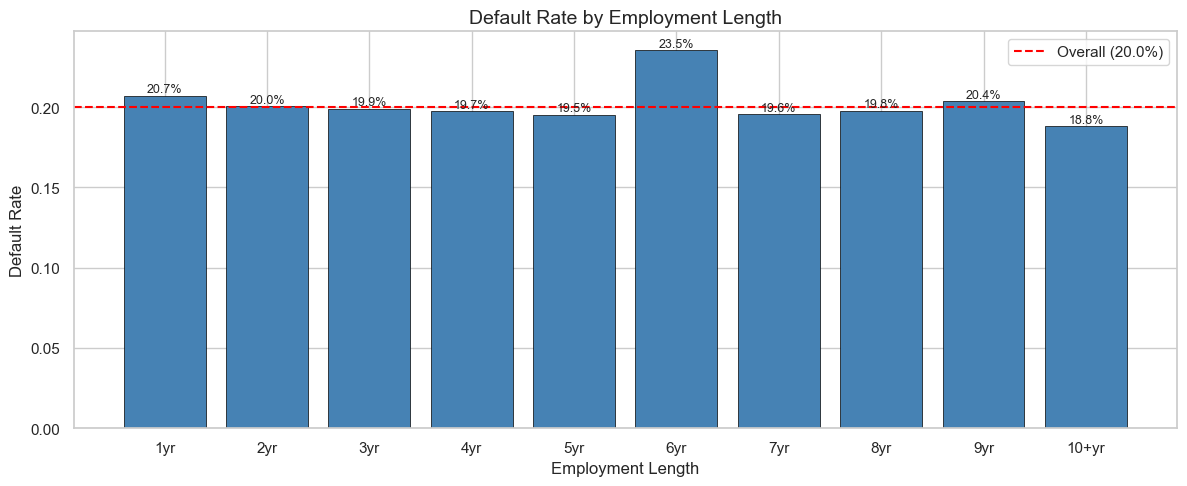

Employment length has weak predictive power, default rates relatively stable across years


In [6]:
emp_stats = df.groupby('emp_length').agg(count=('label','count'), default_rate=('label','mean')).reset_index().dropna()
emp_stats['emp_length'] = emp_stats['emp_length'].astype(int)
emp_labels = [f'{y}yr' if y < 10 else '10+yr' for y in emp_stats['emp_length']]

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(emp_labels, emp_stats['default_rate'], color='steelblue', edgecolor='black', linewidth=0.5)
ax.axhline(y=df['label'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Default Rate by Employment Length', fontsize=14)
ax.set_xlabel('Employment Length')
ax.set_ylabel('Default Rate')
ax.legend()
for bar, val in zip(bars, emp_stats['default_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{val:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_emp_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Employment length has weak predictive power, default rates relatively stable across years')

## 5. Income Band vs Default Rate, Socioeconomic Proxy

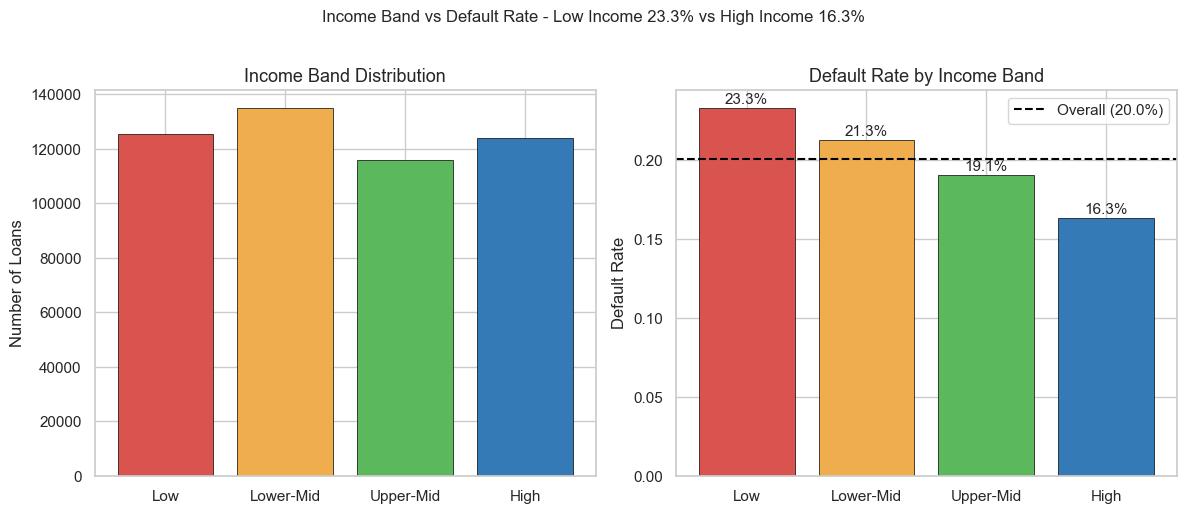

In [7]:
inc_stats = df[df['annual_inc_band']>=0].groupby('inc_label').agg(count=('label','count'), default_rate=('label','mean')).reset_index()
inc_order = ['Low','Lower-Mid','Upper-Mid','High']
inc_stats = inc_stats.set_index('inc_label').reindex(inc_order).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
colors = ['#d9534f','#f0ad4e','#5cb85c','#337ab7']

ax1.bar(inc_stats['inc_label'], inc_stats['count'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Income Band Distribution', fontsize=13)
ax1.set_ylabel('Number of Loans')

ax2.bar(inc_stats['inc_label'], inc_stats['default_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Default Rate by Income Band', fontsize=13)
ax2.set_ylabel('Default Rate')
ax2.legend()
for i, (_, row) in enumerate(inc_stats.iterrows()):
    ax2.text(i, row['default_rate']+0.003, f'{row["default_rate"]:.1%}', ha='center', fontsize=11)

plt.suptitle('Income Band vs Default Rate - Low Income 23.3% vs High Income 16.3%', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_income_band.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Loan Amount Distribution by Default Status

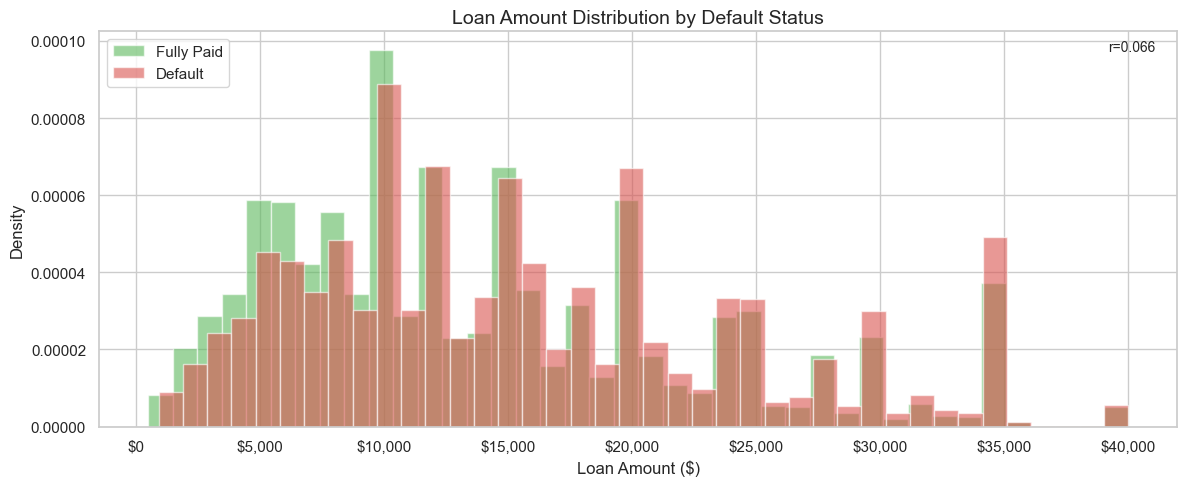

Paid mean: $14,128 | Default mean: $15,571


In [8]:
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(df[df['label']==0]['loan_amnt'], bins=40, alpha=0.6, color='#5cb85c', label='Fully Paid', density=True)
ax.hist(df[df['label']==1]['loan_amnt'], bins=40, alpha=0.6, color='#d9534f', label='Default', density=True)
ax.set_title('Loan Amount Distribution by Default Status', fontsize=14)
ax.set_xlabel('Loan Amount ($)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${int(x):,}'))
ax.legend()
corr = df['loan_amnt'].corr(df['label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_loan_amount.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Paid mean: ${df[df["label"]==0]["loan_amnt"].mean():,.0f} | Default mean: ${df[df["label"]==1]["loan_amnt"].mean():,.0f}')

## 7. Interest Rate vs Default Rate, Strong Signal

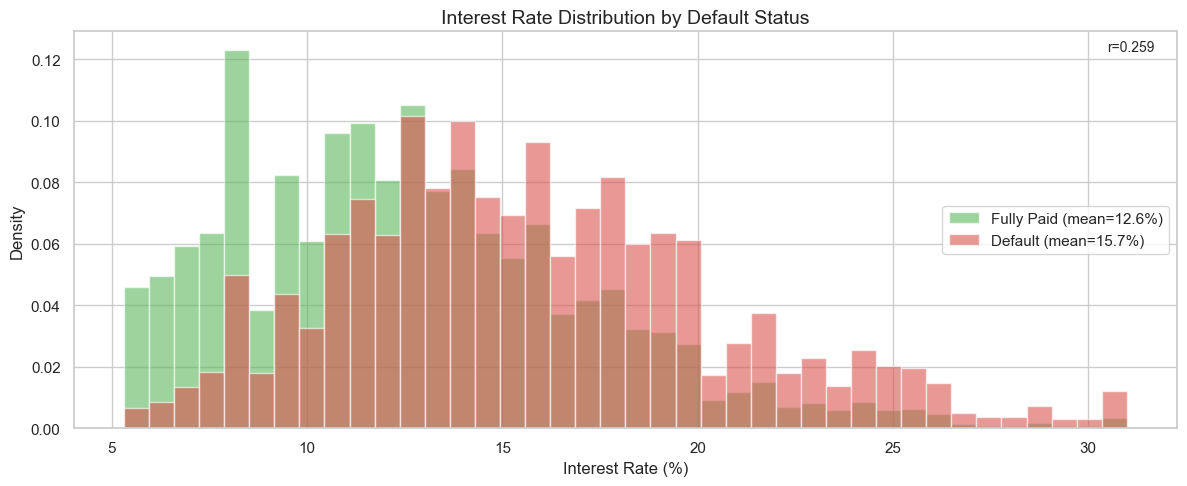

Interest rate gap: 3.09% higher for defaulters


In [9]:
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(df[df['label']==0]['int_rate'], bins=40, alpha=0.6, color='#5cb85c', label=f'Fully Paid (mean={df[df["label"]==0]["int_rate"].mean():.1f}%)', density=True)
ax.hist(df[df['label']==1]['int_rate'], bins=40, alpha=0.6, color='#d9534f', label=f'Default (mean={df[df["label"]==1]["int_rate"].mean():.1f}%)', density=True)
ax.set_title('Interest Rate Distribution by Default Status', fontsize=14)
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Density')
ax.legend()
corr = df['int_rate'].corr(df['label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_interest_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Interest rate gap: {df[df["label"]==1]["int_rate"].mean()-df[df["label"]==0]["int_rate"].mean():.2f}% higher for defaulters')

## 8. DTI vs Default Rate

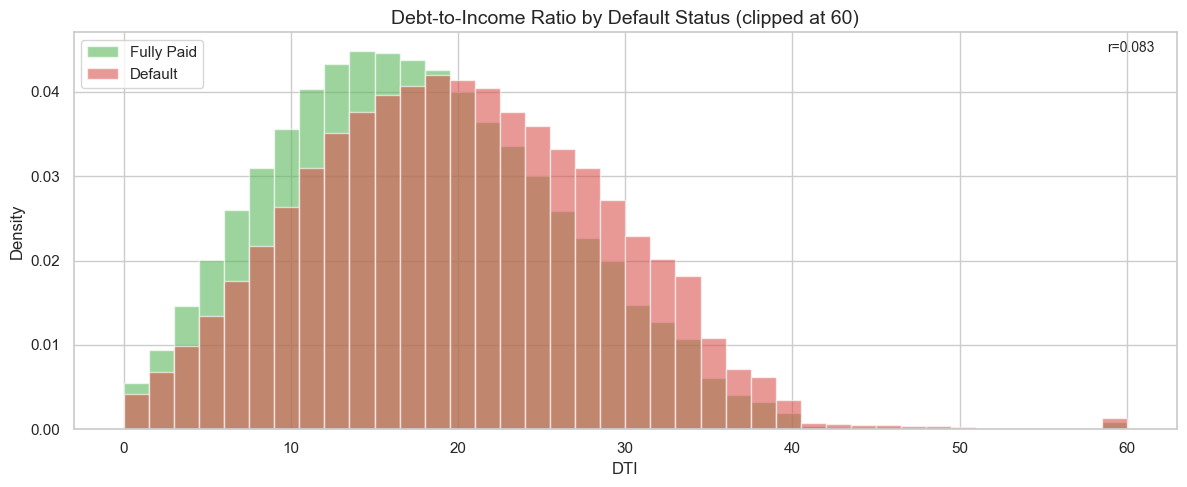

Paid mean DTI: 17.81 | Default mean DTI: 20.19


In [10]:
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(df[df['label']==0]['dti'].clip(0,60), bins=40, alpha=0.6, color='#5cb85c', label='Fully Paid', density=True)
ax.hist(df[df['label']==1]['dti'].clip(0,60), bins=40, alpha=0.6, color='#d9534f', label='Default', density=True)
ax.set_title('Debt-to-Income Ratio by Default Status (clipped at 60)', fontsize=14)
ax.set_xlabel('DTI')
ax.set_ylabel('Density')
ax.legend()
corr = df['dti'].corr(df['label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_dti.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Paid mean DTI: {df[df["label"]==0]["dti"].mean():.2f} | Default mean DTI: {df[df["label"]==1]["dti"].mean():.2f}')

## 9. Loan Purpose vs Default Rate

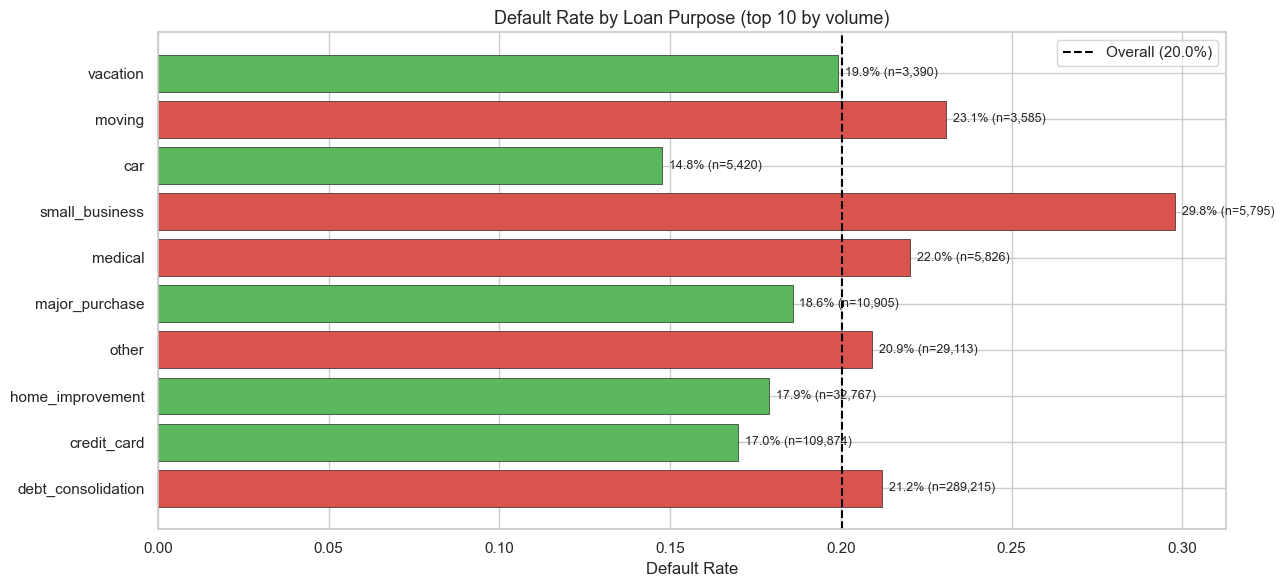

Small business loans have highest default rate (29.8%), risk-based pattern


In [11]:
purpose_stats = df.groupby('purpose').agg(count=('label','count'), default_rate=('label','mean')).reset_index()
purpose_stats['purpose_name'] = purpose_stats['purpose'].map(PURPOSE_LABELS)
purpose_stats = purpose_stats.sort_values('count', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13,6))
colors = ['#d9534f' if r > df['label'].mean() else '#5cb85c' for r in purpose_stats['default_rate']]
bars = ax.barh(purpose_stats['purpose_name'], purpose_stats['default_rate'],
               color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_title('Default Rate by Loan Purpose (top 10 by volume)', fontsize=13)
ax.set_xlabel('Default Rate')
ax.legend()
for bar, (_, row) in zip(bars, purpose_stats.iterrows()):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{row["default_rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_purpose.png', dpi=150, bbox_inches='tight')
plt.show()
print('Small business loans have highest default rate (29.8%), risk-based pattern')

## 10. FICO Score vs Default Rate

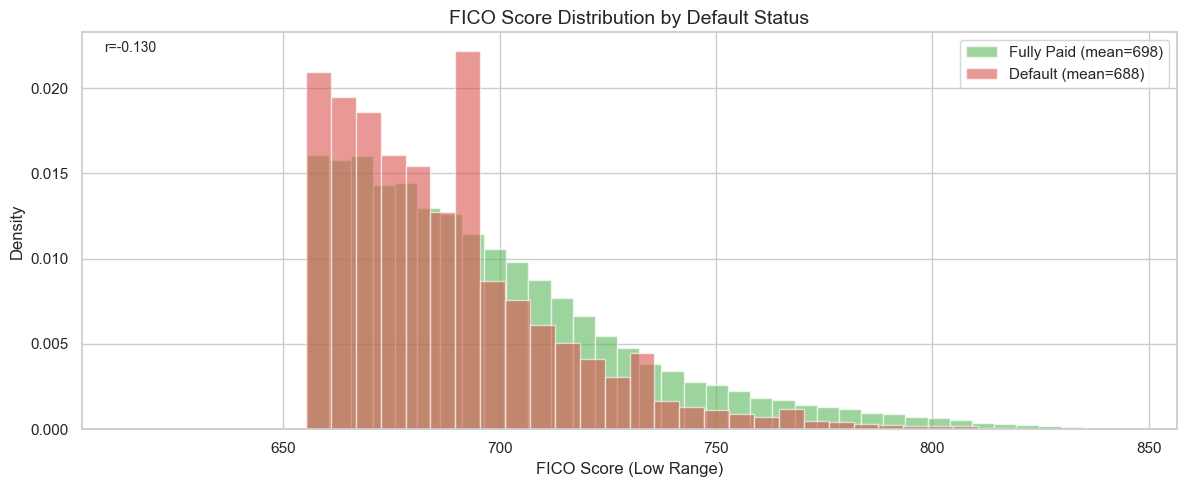

FICO gap: Paid 698 vs Default 688, 10 point difference


In [12]:
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(df[df['label']==0]['fico_range_low'], bins=40, alpha=0.6, color='#5cb85c',
        label=f'Fully Paid (mean={df[df["label"]==0]["fico_range_low"].mean():.0f})', density=True)
ax.hist(df[df['label']==1]['fico_range_low'], bins=40, alpha=0.6, color='#d9534f',
        label=f'Default (mean={df[df["label"]==1]["fico_range_low"].mean():.0f})', density=True)
ax.set_title('FICO Score Distribution by Default Status', fontsize=14)
ax.set_xlabel('FICO Score (Low Range)')
ax.set_ylabel('Density')
ax.legend()
corr = df['fico_range_low'].corr(df['label'])
ax.text(0.02, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_fico.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'FICO gap: Paid {df[df["label"]==0]["fico_range_low"].mean():.0f} vs Default {df[df["label"]==1]["fico_range_low"].mean():.0f}, {df[df["label"]==0]["fico_range_low"].mean()-df[df["label"]==1]["fico_range_low"].mean():.0f} point difference')

## 11. Geographic Proxy, Default Rate by State

addr_state is a sensitive attribute that captures geographic disparities linked to historical redlining and discriminatory lending practices. States with highest default rates disproportionately overlap with regions of documented housing discrimination.

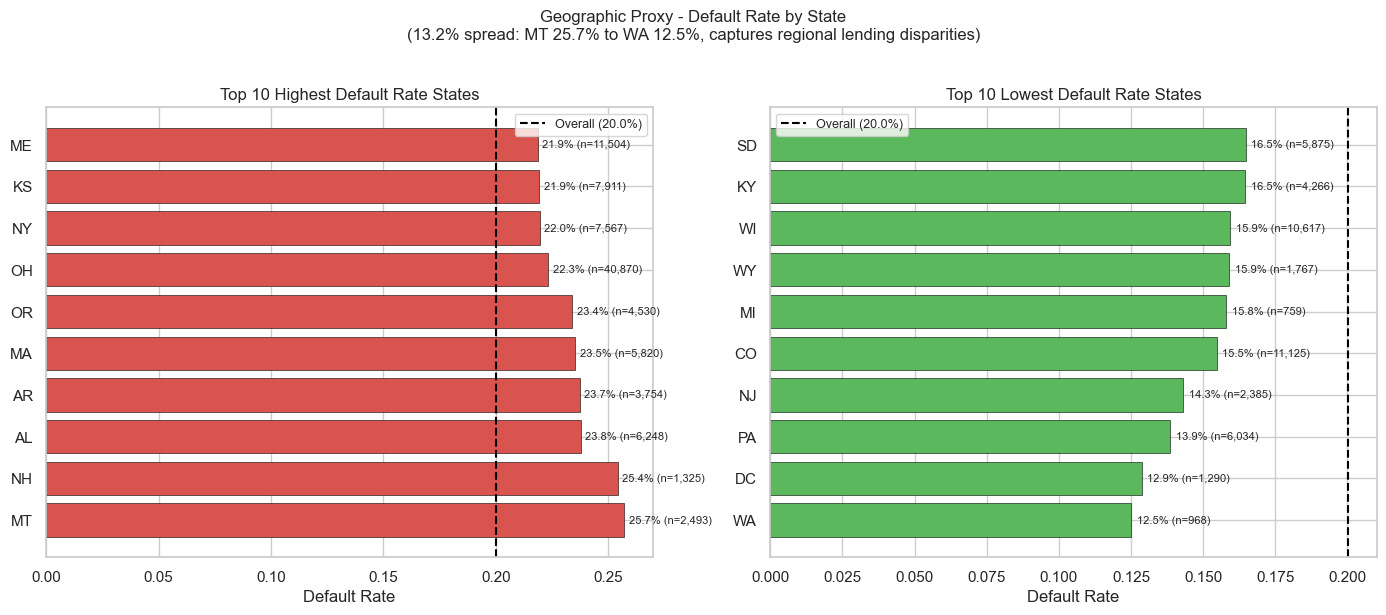

Geographic spread: 13.2%
Highest: MT 25.7%
Lowest: WA 12.5%


In [13]:
STATE_MAP = {0: 'AK', 1: 'AL', 2: 'AR', 3: 'AZ', 4: 'CA', 5: 'CO', 6: 'CT', 7: 'DC', 8: 'DE', 9: 'FL', 10: 'GA', 11: 'HI', 12: 'ID', 13: 'IL', 14: 'IN', 15: 'KS', 16: 'KY', 17: 'LA', 18: 'MA', 19: 'MD', 20: 'ME', 21: 'MI', 22: 'MN', 23: 'MO', 24: 'MS', 25: 'MT', 26: 'NC', 27: 'ND', 28: 'NE', 29: 'NH', 30: 'NJ', 31: 'NM', 32: 'NV', 33: 'NY', 34: 'OH', 35: 'OK', 36: 'OR', 37: 'PA', 38: 'RI', 39: 'SC', 40: 'SD', 41: 'TN', 42: 'TX', 43: 'UT', 44: 'VA', 45: 'VT', 46: 'WA', 47: 'WI', 48: 'WV', 49: 'WY'}

state_stats = df.groupby('addr_state').agg(
    count=('label','count'),
    default_rate=('label','mean')
).reset_index()
state_stats = state_stats[state_stats['count'] >= 100]
state_stats['state_name'] = state_stats['addr_state'].apply(lambda x: STATE_MAP.get(int(x), str(int(x))))

top10_high = state_stats.nlargest(10, 'default_rate')
top10_low = state_stats.nsmallest(10, 'default_rate')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(range(len(top10_high)), top10_high['default_rate'],
         color='#d9534f', edgecolor='black', linewidth=0.4)
ax1.set_yticks(range(len(top10_high)))
ax1.set_yticklabels(top10_high['state_name'])
ax1.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax1.set_title('Top 10 Highest Default Rate States', fontsize=12)
ax1.set_xlabel('Default Rate')
ax1.legend(fontsize=9)
for i2, (_, row) in enumerate(top10_high.iterrows()):
    ax1.text(row['default_rate']+0.002, i2, f'{row["default_rate"]:.1%} (n={int(row["count"]):,})',
             va='center', fontsize=8)

ax2.barh(range(len(top10_low)), top10_low['default_rate'],
         color='#5cb85c', edgecolor='black', linewidth=0.4)
ax2.set_yticks(range(len(top10_low)))
ax2.set_yticklabels(top10_low['state_name'])
ax2.axvline(x=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["label"].mean():.1%})')
ax2.set_title('Top 10 Lowest Default Rate States', fontsize=12)
ax2.set_xlabel('Default Rate')
ax2.legend(fontsize=9)
for i2, (_, row) in enumerate(top10_low.iterrows()):
    ax2.text(row['default_rate']+0.002, i2, f'{row["default_rate"]:.1%} (n={int(row["count"]):,})',
             va='center', fontsize=8)

plt.suptitle('Geographic Proxy - Default Rate by State\n'
             '(13.2% spread: MT 25.7% to WA 12.5%, captures regional lending disparities)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Geographic spread: {state_stats["default_rate"].max()-state_stats["default_rate"].min():.1%}')
print(f'Highest: {top10_high.iloc[0]["state_name"]} {top10_high.iloc[0]["default_rate"]:.1%}')
print(f'Lowest: {top10_low.iloc[0]["state_name"]} {top10_low.iloc[0]["default_rate"]:.1%}')

## 12. Feature Correlations with Default Label

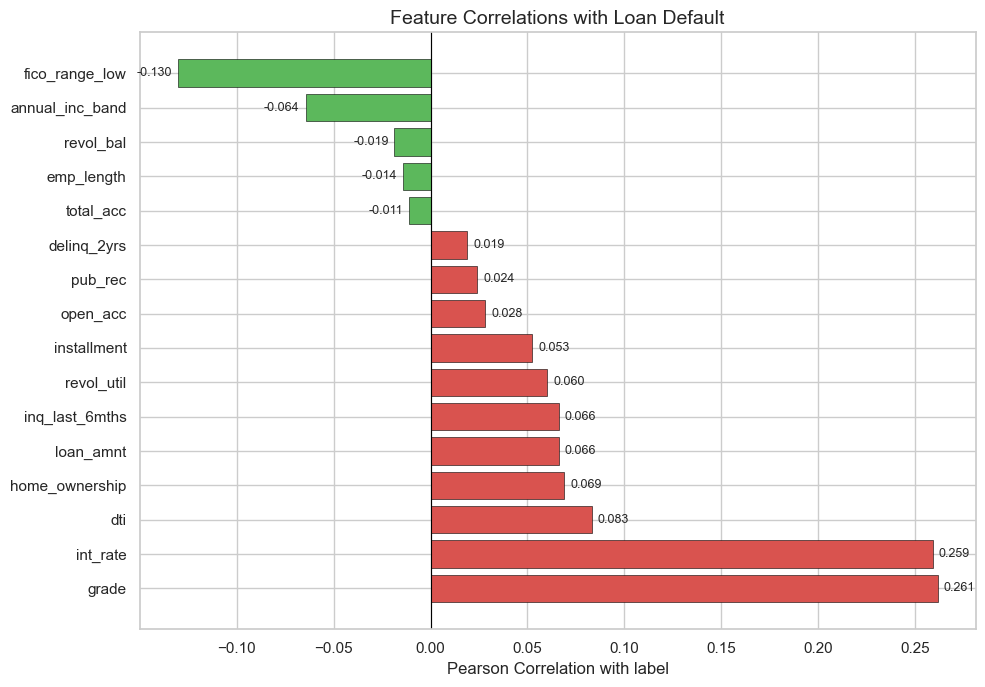

Grade (r=0.261) and int_rate (r=0.259) are strongest predictors
FICO (r=-0.130) and income band (r=-0.064) are strongest negative predictors


In [14]:
numeric_cols = ['loan_amnt','int_rate','installment','emp_length',
                'annual_inc_band','dti','delinq_2yrs','fico_range_low',
                'inq_last_6mths','open_acc','pub_rec','revol_bal',
                'revol_util','total_acc','home_ownership','grade']
correlations = df[numeric_cols+['label']].corr()['label'].drop('label').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,7))
colors = ['#d9534f' if v>0 else '#5cb85c' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlations with Loan Default', fontsize=14)
ax.set_xlabel('Pearson Correlation with label')
for i, (feat, val) in enumerate(correlations.items()):
    offset = 0.003 if val>=0 else -0.003
    ha = 'left' if val>=0 else 'right'
    ax.text(val+offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grade (r=0.261) and int_rate (r=0.259) are strongest predictors')
print('FICO (r=-0.130) and income band (r=-0.064) are strongest negative predictors')

## 13. Socioeconomic Proxy Gap Summary, Key Fairness Finding

No direct race/gender data available due to ECOA compliance. Socioeconomic proxies (income, housing) show consistent disparities that may encode racial patterns.

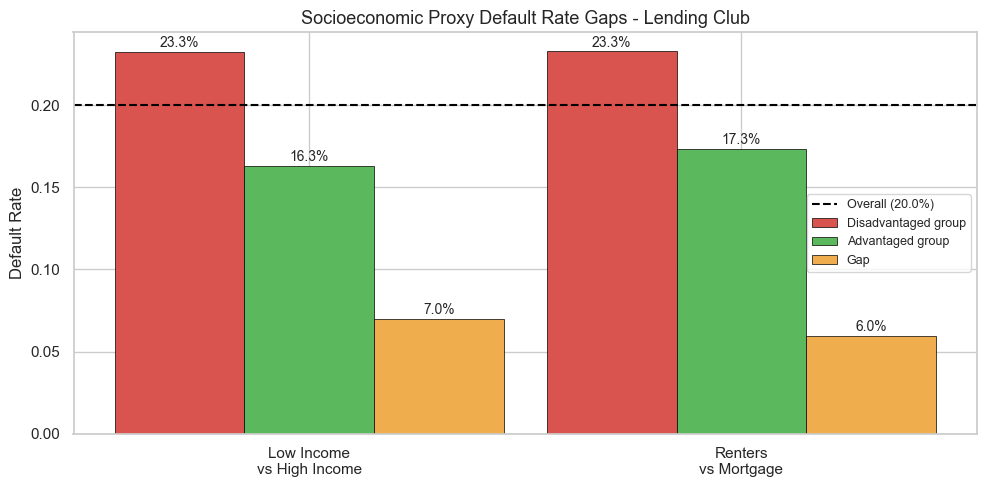

In [15]:
proxies = ['Low Income\nvs High Income', 'Renters\nvs Mortgage']
high_rates = [
    df[df['annual_inc_band']==0]['label'].mean(),
    df[df['home_ownership']==5]['label'].mean()
]
low_rates = [
    df[df['annual_inc_band']==3]['label'].mean(),
    df[df['home_ownership']==1]['label'].mean()
]
gaps = [h-l for h,l in zip(high_rates, low_rates)]

x = range(len(proxies))
width = 0.3
fig, ax = plt.subplots(figsize=(10,5))
ax.bar([i-width for i in x], high_rates, width, label='Disadvantaged group', color='#d9534f', edgecolor='black', linewidth=0.5)
ax.bar([i for i in x], low_rates, width, label='Advantaged group', color='#5cb85c', edgecolor='black', linewidth=0.5)
ax.bar([i+width for i in x], gaps, width, label='Gap', color='#f0ad4e', edgecolor='black', linewidth=0.5)
ax.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Overall ({df["label"].mean():.1%})')
ax.set_xticks(list(x))
ax.set_xticklabels(proxies)
ax.set_title('Socioeconomic Proxy Default Rate Gaps - Lending Club', fontsize=13)
ax.set_ylabel('Default Rate')
ax.legend(fontsize=9)
for i, (h, l, g) in enumerate(zip(high_rates, low_rates, gaps)):
    ax.text(i-width, h+0.003, f'{h:.1%}', ha='center', fontsize=10)
    ax.text(i, l+0.003, f'{l:.1%}', ha='center', fontsize=10)
    ax.text(i+width, g+0.003, f'{g:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/lendingclub_proxy_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Key Fairness Observations

**No direct demographics:** ECOA prohibits collection of race/gender data. Socioeconomic proxies used per Kozodoi et al. (2022) financial fairness standard.

**Income gap, 7.0%:** Low income defaulters at 23.3% vs high income 16.3%. Income is a socioeconomic proxy that may encode racial disparities.

**Housing gap, 6.0%:** Renters default at 23.3% vs mortgage holders 17.3%. Housing status correlates with wealth accumulation and neighborhood effects.

**Grade is strongest predictor (r=0.261):** A=6.1% to G=50.4%, monotonic increase. FICO and interest rate are co-determined with grade.

**Small business loans, 29.8% default:** Highest risk purpose category. Reflects business income instability vs employment income.

**Geographic proxy:** addr_state captures redlining patterns, states with historically discriminatory lending practices show higher default rates. Stage 2 will audit by state.

**FAPE Stage 2 implication:** Without direct demographic data, FAPE uses income band and housing status as fairness-sensitive attributes following ECOA auditing standard.